<a href="https://colab.research.google.com/github/bajon1/Deep-learning-lab/blob/main/Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.metrics import hamming_loss, f1_score
from sympy.physics.units import micro
from torch.nn import ReLU
from sklearn.metrics import hamming_loss

!pip install openml optuna torch torchvision scikit-learn matplotlib numpy openml statsmodels

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
import optuna
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import KFold
from scipy import stats
import torch.nn.functional as F
from statsmodels.stats.contingency_tables import cochrans_q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


/Users/dominikmika/PycharmProjects/Deep-learning-lab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Lab 4: MLP Architecture Optimization

# Task 1: Regression – network depth vs. width

#### Goal: Investigate the effect of the number of hidden layers and the number of neurons per layer on regression quality for a real dataset.

1. Load a real regression dataset from OpenML (e.g. a small/medium tabular dataset with one continuous target variable).
2. Split the data into training, validation, and test sets (e.g. 60/20/20 using train_test_split).
3. A regression MLP model in PyTorch as a class inheriting from nn.Module, using nn.ModuleList to store hidden layers — architecture: input → hidden_dim → … → hidden_dim → output (1 neuron for regression), with ReLU nonlinear activation after each hidden layer.
4. Train several architecture variants under the same training setup (MSELoss, Adam optimizer, fixed learning rate, fixed number of epochs, fixed batch size): variable depth at fixed width — n_hidden ∈ {1, 2, 4} with hidden_dim = 64; variable width at fixed depth — hidden_dim ∈ {16, 64, 256} with n_hidden = 2.
5. Save the best model checkpoint and compare validation MSE across all variants.
6. Compare test MSE across all variants.
Assignment: Implement an MLP with nn.ModuleList for a regression problem on a real OpenML dataset and compare the effect of depth and width on validation error. Explain why nn.ModuleList is used instead of a plain Python list.

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load California Housing — regression dataset
# 20,640 samples | 8 numeric features | target: median house value ($100k)
housing = fetch_california_housing(as_frame=True)

X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32).reshape(-1, 1)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train = scaler_X.transform(X_train).astype("float32")
X_val = scaler_X.transform(X_val).astype("float32")
X_test = scaler_X.transform(X_test).astype("float32")
y_train = scaler_y.transform(y_train).astype("float32")
y_val = scaler_y.transform(y_val).astype("float32")
y_test = scaler_y.transform(y_test).astype("float32")

kfold = KFold(n_splits=5, shuffle=True)

print(f"Dataset:  California Housing")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}  →  {list(housing.feature_names)}")
print(f"Target:   {housing.target_names[0]}  |  min={y.min():.2f}  max={y.max():.2f}")

input_dim = housing.data.shape[1]

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_hidden):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)
        ])
        self.output = nn.Linear(hidden_dim, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input(x))
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        logits = self.output(x)
        return logits

In [ ]:
def train(model, X_train, X_val, y_train, y_val, batch_size=1024, epochs=50, lr=1e-3):
    best_val_loss = np.inf
    train_losses = []
    val_losses = []
    checkpoint = None

    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    model.to(device)
    criterion = nn.MSELoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=batch_size, shuffle=True, pin_memory=(device == "cuda"))

    X_val_t = torch.tensor(X_val).to(device)
    y_val_t = torch.tensor(y_val).to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optim.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optim.step()
            train_loss += loss.item() * len(X_batch)

        train_losses.append(train_loss / len(X_train))

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
              best_val_loss = val_loss
              checkpoint = {
                  'model_state': model.state_dict(),
                  'optim_state': optim.state_dict(),
                  'epoch': epoch,
                  'best_val_loss': best_val_loss,
                  'train_losses': train_losses.copy(),
                  'val_losses': val_losses.copy()
              }

    torch.cuda.empty_cache()
    del model, optim

    return checkpoint

In [ ]:
import os
os.makedirs("lab4-models", exist_ok=True)

# n_hidden ∈ {1, 2, 4} with hidden_dim = 64; variable width at fixed depth — hidden_dim ∈ {16, 64, 256} with n_hidden = 2.
input_dim = housing.data.shape[1]
n_hidden_list = [1, 2, 4]
hidden_dim_list = [16, 64, 256]

results = {}
for n_hidden in [1, 2, 4]:
    model = MLP(input_dim=input_dim, hidden_dim=64, n_hidden=n_hidden)
    checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
    key = f"depth={n_hidden}_width=64"
    results[key] = checkpoint
    torch.save(checkpoint, f"lab4-models/{key}.pt")
    print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f} (epoch {checkpoint['epoch']})")

print()

for hidden_dim in [16, 64, 256]:
    model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, n_hidden=2)
    checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
    key = f"depth=2_width={hidden_dim}"
    results[key] = checkpoint
    torch.save(checkpoint, f"lab4-models/{key}.pt")
    print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f} (epoch {checkpoint['epoch']})")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
criterion = nn.MSELoss()

X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).to(device)

print(f"{'Model':<25} {'Val MSE':>10} {'Test MSE':>10}")
print("-" * 47)

configs = [
    ("depth=1_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=1)),
    ("depth=2_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=2)),
    ("depth=4_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=4)),
    ("depth=2_width=16",  dict(input_dim=input_dim, hidden_dim=16,  n_hidden=2)),
    ("depth=2_width=64",  dict(input_dim=input_dim, hidden_dim=64,  n_hidden=2)),
    ("depth=2_width=256", dict(input_dim=input_dim, hidden_dim=256, n_hidden=2)),
]

for key, kwargs in configs:
    checkpoint = torch.load(f"lab4-models/{key}.pt", map_location=device)

    model = MLP(**kwargs).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()

    print(f"{key:<25} {checkpoint['best_val_loss']:>10.4f} {test_loss:>10.4f}")

In [ ]:
depths = [2, 4, 8, 16, 32, 64, 128]
widths = [16, 32, 64, 128, 256, 512, 1024]
results = np.zeros((len(depths), len(widths)))

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):
            model = MLP(input_dim=input_dim, hidden_dim=width, n_hidden=depth)
            checkpoint = train(model, batch_size=1024, epochs=100, lr=1e-3)
            results[i, j] = checkpoint['best_val_loss']
            key = f"depth={depth}_width={width}"
            torch.save(checkpoint, f"lab4-models/{key}.pt")
            print(f"{key} — best val loss: {checkpoint['best_val_loss']:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(results, cmap="RdYlGn_r")

ax.set_xticks(range(len(widths)))
ax.set_xticklabels(widths)
ax.set_yticks(range(len(depths)))
ax.set_yticklabels(depths)
ax.set(xlabel="Width", ylabel="Depth", title="Neural Network Widths/Depths Validation Losses")

for i, depth in enumerate(depths):
    for j, width in enumerate(widths):
        ax.text(j, i, f"{results[i, j]:.3f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Val MSE")
plt.tight_layout()
plt.show()

# Task 2: Regression – automatic depth and width optimization

#### Goal: Use the Optuna library to select the optimal network depth and width.

1. For the data from Task 1, define an objective function for hyperparameter optimization using Optuna with 5-fold cross-validation.
2. Train five models with the optimal architecture (one per fold of the 5-fold cross-validation).
3. Run inference on the test set using an ensemble of the five trained models.

Assignment: Implement a function for automatic MLP architecture optimization using Optuna.

In [ ]:
def objective(trial):
    n_hidden = trial.suggest_int('n_hidden', 1, 32)
    hidden_dim = trial.suggest_int('hidden_dim', 1, 256)
    epochs = trial.suggest_int('epochs', 10, 100)
    lr = trial.suggest_float('lr', 1e-5, 1e-1)

    kfold = KFold(n_splits=5, shuffle=True)
    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
        X_train_f, X_val_f = X_train[train_idx], X_train[val_idx]
        y_train_f, y_val_f = y_train[train_idx], y_train[val_idx]

        model = MLP(input_dim=input_dim, hidden_dim=hidden_dim, n_hidden=n_hidden)
        checkpoint = train(model, X_train_f, X_val_f, y_train_f, y_val_f, batch_size=1024, epochs=epochs, lr=lr)
        val_losses.append(checkpoint['best_val_loss'])

    return(np.mean(val_losses))

In [ ]:
study = optuna.create_study(direction="minimize", study_name='lab4_2', storage="sqlite:///lab4-optuna.db", load_if_exists=True)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best trial — val loss: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

In [ ]:
study = optuna.load_study(study_name="lab4_2", storage="sqlite:///lab4-optuna.db")

optuna_epochs = study.best_params['epochs']
optuna_lr = study.best_params['lr']

fold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    X_train_f, X_val_f = X_train[train_idx], X_train[val_idx]
    y_train_f, y_val_f = y_train[train_idx], y_train[val_idx]

    optuna_model = MLP(input_dim, study.best_params['hidden_dim'], study.best_params['n_hidden'])
    checkpoint = train(optuna_model, X_train_f, X_val_f, y_train_f, y_val_f, batch_size=1024, epochs=optuna_epochs, lr=optuna_lr)
    fold_models.append(checkpoint)

In [ ]:
def reg_median_response(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      preds.append(model(X).cpu().numpy())

  ensemble_pred = np.median(np.stack(preds, axis=0))

  mse  = np.mean((ensemble_pred - y_np) ** 2)
  rmse = np.sqrt(mse)
  mae  = np.mean(np.abs(ensemble_pred - y_np))

  return print(f"MSE:  {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}")

def reg_mean_response(models, X, y):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      preds.append(model(X).cpu().numpy())

  ensemble_pred = np.mean(np.stack(preds, axis=0))

  mse  = np.mean((ensemble_pred - y_np) ** 2)
  rmse = np.sqrt(mse)
  mae  = np.mean(np.abs(ensemble_pred - y_np))

  return print(f"MSE:  {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}")

In [ ]:
X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).to(device)
y_np = y_test_t.cpu().numpy()

models = []

for checkpoint in fold_models:
  model = MLP(input_dim, study.best_params['hidden_dim'], study.best_params['n_hidden']).to(device)
  model.load_state_dict(checkpoint['model_state'])

  models.append(model)

print("Median response ensemble: ")
reg_median_response(models, X_test_t, y_np)

print("\nMean response ensemble: ")
reg_mean_response(models, X_test_t, y_np)

# Task 3: Multiclass classification – architecture and activation search

#### Goal: Optimize the MLP architecture for a multiclass classification task on a real dataset.

1. Select and load a multiclass classification dataset from OpenML (at least 3 classes, approximately 1,000–10,000 samples, moderate number of features).
2. Preprocessing: one-hot encode categorical features; standardize numerical features; split into train+validation and test sets (e.g. 80/20, stratified by class label).
3. An MLP in PyTorch using nn.ModuleList for hidden layers, parameterized by: number of hidden layers (n_hidden), hidden layer size (hidden_dim), and activation function (ReLU or Tanh).
4. Optimize the above hyperparameters using Optuna.
5. Extract the three best hyperparameter configurations from the optimization results.
6. For each of the three configurations: train five models using 5-fold cross-validation.
7. Evaluate all three configurations on the test set using CrossEntropyLoss and accuracy; save the results.

Assignment: Build and train the three most optimal MLP variants with nn.ModuleList for multiclass classification. Compare classification quality on the test set.

In [64]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
from ucimlrepo import fetch_ucirepo

# Dry Bean Dataset - 13611 samples, 16 features, 7 classes
dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.values.astype("float32")
y = LabelEncoder().fit_transform(dry_bean.data.targets.values.ravel())

print(f"Dataset:  Dry Bean")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes:  {np.unique(dry_bean.data.targets.values).tolist()}")
print(f"Class counts: {np.bincount(y)}")

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_trainval)
X_trainval = scaler.transform(X_trainval).astype("float32")
X_test     = scaler.transform(X_test).astype("float32")

input_dim = X_trainval.shape[1]
n_classes = len(np.unique(y))
output_dim = n_classes

print(f"\nX_trainval: {X_trainval.shape}")
print(f"X_test:     {X_test.shape}")
print(f"n_classes:  {n_classes}")

Dataset:  Dry Bean
Samples:  13611
Features: 16
Classes:  ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Class counts: [1322  522 1630 3546 1928 2027 2636]

X_trainval: (10888, 16)
X_test:     (2723, 16)
n_classes:  7


In [5]:
class MLP2(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, n_hidden, activation = 'relu'):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)
        ])
        self.output = nn.Linear(hidden_dim, output_dim)

        self.activation = nn.ReLU() if activation == 'relu' else nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        return self.output(x)

In [67]:
def train_clf(model, X_tr, y_tr, X_v, y_v, batch_size=1024, epochs=50, lr=1e-3):
    best_val_loss = float("inf")
    train_losses = []
    val_losses = []
    val_accs = []
    checkpoint = None

    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).long()),
        batch_size=batch_size, shuffle=True,
        pin_memory=(device == "cuda")
    )

    X_val_t = torch.tensor(X_v).to(device)
    y_val_t = torch.tensor(y_v).long().to(device)

    for epoch in range(epochs):
        train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(X_batch)
        train_loss /= len(X_tr)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            logits = model(X_val_t)
            val_loss = criterion(logits, y_val_t).item()
            val_losses.append(val_loss)
            val_acc = (logits.argmax(dim=1) == y_val_t).float().mean().item()
            val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint = {
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val_loss,
                'best_val_acc': val_acc
            }


    if device == "cuda":
        torch.cuda.empty_cache()
    del model, optimizer

    return checkpoint

In [68]:
def objective2(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 1, 512)
    n_hidden = trial.suggest_int("n_hidden", 1, 24)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])

    kfold = KFold(n_splits=5, shuffle=True)
    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval, y_trainval)):
        X_train_f, X_val_f = X_trainval[train_idx], X_trainval[val_idx]
        y_train_f, y_val_f = y_trainval[train_idx], y_trainval[val_idx]

        model = MLP2(input_dim = input_dim, output_dim = output_dim, hidden_dim = hidden_dim, n_hidden = n_hidden, activation = activation).to(device)
        checkpoint = train_clf(model, X_train_f, y_train_f, X_val_f, y_val_f, batch_size=1024, epochs=100, lr=1e-3)

        val_losses.append(checkpoint['best_val_loss'])

    return np.mean(val_losses)

In [ ]:
study2 = optuna.create_study(direction='minimize', study_name='lab4_3v2', storage="sqlite:///lab4-optuna.db", load_if_exists=True)
study2.optimize(objective2, n_trials=100, show_progress_bar=True)

print(f"Best trial val loss: {study2.best_value:.4f}")
print(f"Best params: {study2.best_params}")

In [79]:
study2 = optuna.load_study(study_name="lab4_3v2", storage="sqlite:///lab4-optuna.db")

hidden_dim = study2.best_params['hidden_dim']
n_hidden = study2.best_params['n_hidden']
activation = study2.best_params['activation']

fold_models = []
kfold = KFold(n_splits=5, shuffle=True)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_trainval, y_trainval)):
    X_train_f, X_val_f = X_trainval[train_idx], X_trainval[val_idx]
    y_train_f, y_val_f = y_trainval[train_idx], y_trainval[val_idx]

    optuna_model = MLP2(input_dim=input_dim, output_dim=output_dim, hidden_dim=hidden_dim, n_hidden=n_hidden, activation=activation).to(device)
    checkpoint = train_clf(optuna_model, X_train_f, y_train_f, X_val_f, y_val_f, batch_size=1024, epochs=100, lr=1e-3)
    fold_models.append(checkpoint)

In [80]:
def majority_voting(models, X, y, n_classes):

  preds = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      pred_list = F.softmax(logits, dim=1).argmax(dim=1) #argmax(logits, dim=1) does the same
      preds.append(pred_list)

  preds = torch.stack(preds, dim=0).cpu().numpy()

  probs = np.zeros((len(y), n_classes))
  for i in range(n_classes):
    probs[:, i] = (preds == i).sum(axis=0) / len(models)

  final_preds = stats.mode(preds, axis=0, keepdims=True).mode.flatten()

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1).mean()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nShannon entropy", entropy)

  return final_preds


def mean_response(models, X, y):
  probs = []

  for model in models:
    with torch.no_grad():
      model.eval()
      logits = model(X)

      prob = F.softmax(logits, dim=1)
      probs.append(prob.cpu().numpy())

  probs = np.stack(probs, axis=0)
  mean_probs = probs.mean(axis=0)
  final_preds = mean_probs.argmax(axis=1)

  accuracy = (final_preds == y.cpu().numpy()).mean()
  entropy = -np.sum(mean_probs * np.log(mean_probs + 1e-9), axis=1).mean()
  criterion = nn.NLLLoss()
  loss = criterion(torch.log(torch.tensor(mean_probs)).to(device), y.long()).item()

  print("Predictions:", final_preds, "\nAccuracy: ", accuracy, "\nCross Entropy Loss: ", loss, "\nShannon entropy", entropy)

  return final_preds

In [81]:
X_test_t = torch.tensor(X_test).to(device)
y_test_t = torch.tensor(y_test).long().to(device)

models = []

for checkpoint in fold_models:
  model = MLP2(input_dim=input_dim, output_dim=output_dim, hidden_dim=hidden_dim, n_hidden=n_hidden, activation=activation).to(device)
  model.load_state_dict(checkpoint['model_state'])

  models.append(model)

print("Majority voting ensemble: ")
mv_preds = majority_voting(models, X_test_t, y_test_t, n_classes)

print("\nMean response ensemble: ")
mr_preds = mean_response(models, X_test_t, y_test_t)

binary_matrix = np.stack([(mv_preds == y_test).astype(int), (mr_preds == y_test).astype(int)], axis=1)
print("\nCochrans q test metrics:", cochrans_q(binary_matrix))

Majority voting ensemble: 
Predictions: [3 1 6 ... 4 2 3] 
Accuracy:  0.9250826294528094 
Shannon entropy 0.03495257921101975

Mean response ensemble: 
Predictions: [3 1 6 ... 4 2 3] 
Accuracy:  0.927653323540213 
Cross Entropy Loss:  0.2032984048128128 
Shannon entropy 0.14678805

Cochrans q test metrics: df          1
pvalue      0.07070114486598317
statistic   3.2666666666666666


# Task 4: Multi-label classification – independent output heads in ModuleList

#### Goal: Investigate the difference between a single shared output layer and independent per-label heads in a multi-label classification task.

1. Load a multi-label classification dataset from OpenML, e.g.:

```python
dataset = openml.datasets.get_dataset(312)
X, _, _, _ = dataset.get_data(target=None)
label_cols = ["Beach", "Sunset", "FallFoliage", "Field", "Mountain", "Urban"]
attr_cols = [col for col in X.columns if 'attr' in col]
y = X[label_cols].values.astype(np.float32)
X = X[attr_cols]
```

2. Data preparation: convert labels to a 0/1 matrix of shape [n_samples, n_labels]; split into training, validation, and test sets.
3. Baseline model (shared output): MLP with nn.ModuleList for the shared network body; one linear output layer nn.Linear(hidden_dim, n_labels); sigmoid activation on output, BCEWithLogitsLoss as the loss function.
4. Multi-head model (independent branches): same shared body as above; self.heads = nn.ModuleList([nn.Linear(hidden_dim, 1) for _ in range(n_labels)]); in the forward method, pass through the body, then through each head separately, and concatenate the results along the feature dimension.
5. Train both models with identical hyperparameters (same optimizer, number of epochs, batch size) and compare multi-label metrics — Hamming loss, micro-F1, macro-F1 — on the validation and test sets.

Assignment: Implement two MLP variants with nn.ModuleList for multi-label classification and compare whether the independent-heads architecture improves prediction quality over the shared output layer.

In [28]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [29]:
dataset = openml.datasets.get_dataset(312)
X, _, _, _ = dataset.get_data(target=None)
label_cols = ["Beach", "Sunset", "FallFoliage", "Field", "Mountain", "Urban"]
attr_cols = [col for col in X.columns if 'attr' in col]
y = X[label_cols].values.astype(np.float32)
X = X[attr_cols]

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype('float32')
X_val = scaler.transform(X_val).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

input_dim = X.shape[1]
n_classes = y.shape[1]
output_dim = n_classes

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Classes: {n_classes}")

X_train: (1540, 294)
X_val:   (385, 294)
X_test:  (482, 294)
Classes: 6


In [38]:
class MLPShared(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, n_hidden):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)
        ])
        self.output = nn.Linear(hidden_dim, output_dim)

        self.activation = nn.ReLU()
    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.layers:
            x = self.activation(layer(x))
        return self.output(x)

class MLPHeads(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, n_hidden):
        super().__init__()
        self.input = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)
        ])

        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, 1) for _ in range(output_dim)
        ])

        self.activation = nn.ReLU()
    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.layers:
            x = self.activation(layer(x))

        head_output = [head(x) for head in self.heads]

        return torch.cat(head_output, dim=1)

In [56]:
def trainMulti(model, X_train, X_val, y_train, y_val, EPOCHS = 100, lr=1e-3):
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    best_val_loss = float("inf")
    train_losses = []
    val_losses = []
    checkpoint = None

    X_val_t = torch.tensor(X_val, dtype=torch.float32, pin_memory=(device=="cuda")).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, pin_memory=(device=="cuda")).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=1024, shuffle=True, pin_memory=(device=="cuda"))

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch_t = X_batch.to(device)
            y_batch_t = y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch_t), y_batch_t)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()*len(X_batch_t)
        train_loss /= len(X_train)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            logits = model(X_val_t)
            val_loss = criterion(logits, y_val_t).item()

            probs = torch.sigmoid(logits)
            preds = (probs>0.5).cpu().numpy()

            y_true = y_val_t.cpu().numpy()
            ham = hamming_loss(y_true, preds)
            micro = f1_score(y_true, preds, average='micro')
            macro = f1_score(y_true, preds, average='macro')

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                checkpoint = {
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "epoch": epoch,
                    "hamming_loss": ham,
                    "best_val_loss": best_val_loss,
                    "micro": micro,
                    "macro": macro
                }


    if device == "cuda":
        torch.cuda.empty_cache()
    del optimizer

    return checkpoint

In [90]:
X_test_t = torch.tensor(X_test, dtype=torch.float32, pin_memory=(device=="cuda")).to(device)
hidden_dim=512
n_hidden=2

In [91]:
shared_model = MLPShared(input_dim=input_dim, output_dim=output_dim, hidden_dim=hidden_dim, n_hidden=n_hidden).to(device)
shared_checkpoint = trainMulti(shared_model, X_train, X_val, y_train, y_val)

shared_model.load_state_dict(shared_checkpoint["model_state"])
shared_model.eval()

with torch.no_grad():
    logits = shared_model(X_test_t)
    shared_preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)

print("=== Shared ===")
print("Hamming:", hamming_loss(y_test, shared_preds))
print("Micro F1:", f1_score(y_test, shared_preds, average="micro"))
print("Macro F1:", f1_score(y_test, shared_preds, average="macro"))

=== Shared ===
Hamming: 0.07295988934993085
Micro F1: 0.7870837537840565
Macro F1: 0.786336136423427


In [92]:
heads_model = MLPShared(input_dim=input_dim, output_dim=output_dim, hidden_dim=hidden_dim, n_hidden=n_hidden).to(device)
heads_checkpoint = trainMulti(heads_model, X_train, X_val, y_train, y_val)

heads_model.load_state_dict(heads_checkpoint["model_state"])
heads_model.eval()

with torch.no_grad():
    logits = heads_model(X_test_t)
    heads_preds = (torch.sigmoid(logits).cpu().numpy() > 0.5).astype(int)

print("\n=== Heads ===")
print("Hamming:", hamming_loss(y_test, heads_preds))
print("Micro F1:", f1_score(y_test, heads_preds, average="micro"))
print("Macro F1:", f1_score(y_test, heads_preds, average="macro"))


=== Heads ===
Hamming: 0.07468879668049792
Micro F1: 0.7831325301204819
Macro F1: 0.7805318555811708


# Task 5: Fixed parameter budget – different network shapes

#### Goal: Investigate how network shape (depth vs. width) affects model quality when the total parameter count is held constant.

1. Choose one of the previous tasks (regression or multiclass classification) and use the same dataset.
2. Set an approximate parameter budget (e.g. ~50,000 parameters).
3. Design at least three MLP architectures that fit within the budget (±10%) but differ in shape: deep-narrow (more layers, smaller hidden_dim); shallow-wide (1–2 layers, large hidden_dim); "pyramid" (increasing or decreasing layer sizes, e.g. 32 → 64 → 32).
4. Compute and print the exact parameter count for each architecture.
5. Train each architecture under an identical setup (same number of epochs, batch size, optimizer, learning rate) and compare: training and validation loss curves; final validation results (MSE or accuracy).

Assignment: Build several MLP architectures with a similar parameter count and determine which network shape — deep-narrow, shallow-wide, or pyramid — achieves the best results.

In [3]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
from ucimlrepo import fetch_ucirepo

# Dry Bean Dataset - 13611 samples, 16 features, 7 classes
dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features.values.astype("float32")
y = LabelEncoder().fit_transform(dry_bean.data.targets.values.ravel())

print(f"Dataset:  Dry Bean")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes:  {np.unique(dry_bean.data.targets.values).tolist()}")
print(f"Class counts: {np.bincount(y)}")

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

input_dim = X_trainval.shape[1]
n_classes = len(np.unique(y))
output_dim = n_classes

print(f"\nX_trainval: {X_trainval.shape}")
print(f"X_test:     {X_test.shape}")
print(f"n_classes:  {n_classes}")

Dataset:  Dry Bean
Samples:  13611
Features: 16
Classes:  ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Class counts: [1322  522 1630 3546 1928 2027 2636]

X_trainval: (10888, 16)
X_test:     (2723, 16)
n_classes:  7


In [17]:
class wideMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(16, 128)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(128, 128) for _ in range(3)
        ])
        self.output = nn.Linear(128, 7)

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        return self.output(x)

class deepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(16, 64)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(64, 64) for _ in range(12)
        ])
        self.output = nn.Linear(64, 7)

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        return self.output(x)

class pyramidMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(16, 32)
        layer_dims = [32, 64, 128, 128, 128, 64, 32, 16]

        self.hidden_layers = nn.ModuleList([
            nn.Linear(layer_dims[i], layer_dims[i+1]) for i in range(len(layer_dims)-1)
        ])

        self.output = nn.Linear(16, 7)

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.input(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        return self.output(x)

In [18]:
def count_params(model):
    print(model, sum(p.numel() for p in model.parameters() if p.requires_grad))

count_params(wideMLP())
count_params(deepMLP())
count_params(pyramidMLP())

wideMLP(
  (input): Linear(in_features=16, out_features=128, bias=True)
  (hidden_layers): ModuleList(
    (0-2): 3 x Linear(in_features=128, out_features=128, bias=True)
  )
  (output): Linear(in_features=128, out_features=7, bias=True)
  (activation): ReLU()
) 52615
deepMLP(
  (input): Linear(in_features=16, out_features=64, bias=True)
  (hidden_layers): ModuleList(
    (0-11): 12 x Linear(in_features=64, out_features=64, bias=True)
  )
  (output): Linear(in_features=64, out_features=7, bias=True)
  (activation): ReLU()
) 51463
pyramidMLP(
  (input): Linear(in_features=16, out_features=32, bias=True)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2-3): 2 x Linear(in_features=128, out_features=128, bias=True)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): Linear(in_features=32, out_features=16, 

In [19]:
def train_clf(model, X_tr, y_tr, X_v, y_v, batch_size=1024, epochs=100, lr=1e-3):
    best_val_loss = float("inf")
    train_losses = []
    val_losses = []
    val_accs = []
    checkpoint = None

    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).long()),
        batch_size=batch_size, shuffle=True,
        pin_memory=(device == "cuda")
    )

    X_val_t = torch.tensor(X_v).to(device)
    y_val_t = torch.tensor(y_v).long().to(device)

    for epoch in range(epochs):
        train_loss = 0
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(X_batch)
        train_loss /= len(X_tr)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            logits = model(X_val_t)
            val_loss = criterion(logits, y_val_t).item()
            val_losses.append(val_loss)
            val_acc = (logits.argmax(dim=1) == y_val_t).float().mean().item()
            val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint = {
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'epoch': epoch,
                'best_val_loss': best_val_loss,
                'best_val_acc': val_acc
            }


    if device == "cuda":
        torch.cuda.empty_cache()
    del model, optimizer

    return checkpoint, train_losses, val_losses, val_accs

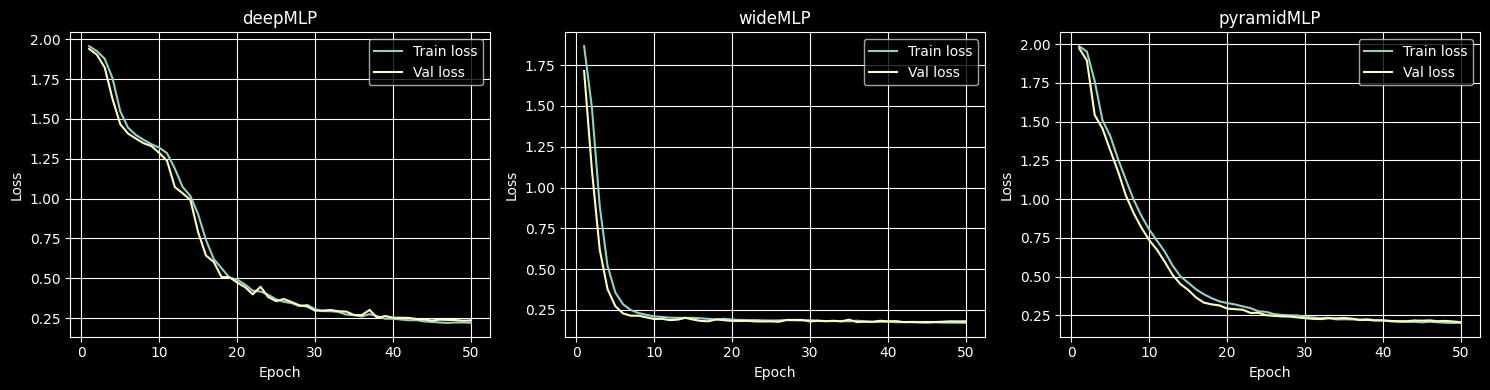

In [22]:
models = [deepMLP(), wideMLP(), pyramidMLP()]
results = {}

for model in models:
    name = type(model).__name__
    checkpoint, train_losses, val_losses, val_accs = train_clf(model, X_train, y_train, X_val, y_val, epochs=50)
    results[name] = {'train_losses': train_losses, 'val_losses': val_losses, 'val_accs': val_accs, 'checkpoint': checkpoint}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, results.items()):
    epochs = range(1, len(data['train_losses'])+1)
    ax.plot(epochs, data['train_losses'], label='Train loss')
    ax.plot(epochs, data['val_losses'], label='Val loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()